In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from typing import Sequence
from modules.backtestdata import DataBuilder, DataLoader
from modules.strategies import MetaStrategy, FixedWeights, Markowitz, MinimumVol
from modules.simulator import BacktestSimulator, wealth_plot
from modules.riskmodel import Riskmodel

In [2]:
riskmodel = Riskmodel.load_from_npz("../data/riskmodel/k10_lb6m_hc6m_hv2m.npz")
return_d = pd.read_parquet("../data/return/return_d.parquet")
rf_d     = pd.read_parquet("../data/return/ffr_d.parquet")
print(return_d.shape, rf_d.shape)

# placeholder alpha
alpha_d = return_d.copy()
alpha_d[:] = 1.0
print(alpha_d.shape)

(8344, 47) (26200, 1)
(8344, 47)


In [12]:
# TODO Implementations:
# - Add d_var to dataloader, used to compute full risk in markowitz and vol control
# - Double triple check for lookahead from riskmodel
# - Carefully go though dataloader, any potential misalignment?

FIRST_DATE = "2005-01-03"
FINAL_DATE = "2024-12-31"
SPREAD = 5e-4
LEVERAGE = 0.0
VC_LIMIT = 0.08 # float("inf")
REBAL_FREQ = "M"

sim = BacktestSimulator(SPREAD)

db = DataBuilder(
    first_date=FIRST_DATE,
    final_date=FINAL_DATE,
    alpha_d=alpha_d,
    return_d=return_d,
    rf_d=rf_d,
    riskmodel=riskmodel,
    rebal_freq=REBAL_FREQ,
)
print(db)

2005-01-03 : 2024-12-31
 :a  - (5033, 47), <class 'numpy.ndarray'>
 :r  - (5033, 47), <class 'numpy.ndarray'>
 :rf - (5033,), <class 'numpy.ndarray'>
 :F  - (5033, 47, 10), <class 'numpy.ndarray'>
 :d  - (5033, 47), <class 'numpy.ndarray'>
 :am - (5033, 47), <class 'numpy.ndarray'>
 :tf - (5033,), <class 'numpy.ndarray'>



Backtest Runtime: 43 ms
Ann Sharpe: 0.6786
Tot Ret:    2.8056
Ann Ret:    0.0692
Ann Vol:    0.0762
Max DD :    0.1674


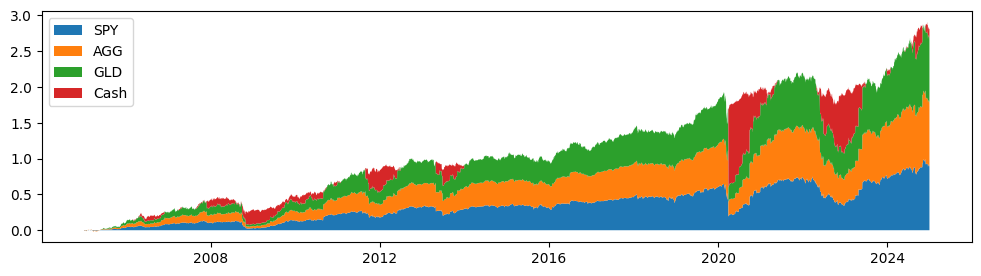

In [20]:
dl = DataLoader(
    tickers=["SPY", "AGG", "GLD"],
    universe=return_d.columns,
    db=db
)

equal_weights = np.ones(dl.N)/dl.N
fw = FixedWeights(
    dl=dl,
    w_rebal=equal_weights,
    lev=LEVERAGE,
    vc_lim=VC_LIMIT,
)
sim.run_backtest(strategy=fw, verbose=True)
wealth_plot(sim)

Backtest Runtime: 2103 ms
Ann Sharpe: 0.5207
Tot Ret:    2.8524
Ann Ret:    0.0699
Ann Vol:    0.1005
Max DD :    0.2925


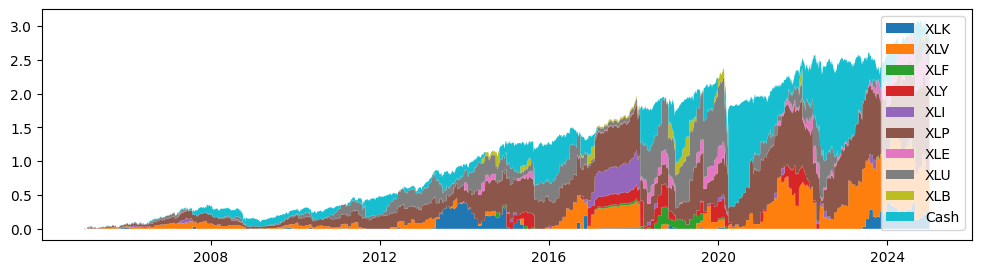

In [21]:
dl = DataLoader(
    tickers=["XLK", "XLV", "XLF", "XLY", "XLI", "XLP", "XLE", "XLU", "XLB"],
    universe=return_d.columns,
    db=db
)

m = Markowitz(
    dl=dl,
    lookahead=0,
    gamma=SPREAD,
    lev=LEVERAGE,
    w_max=0.4*np.ones(dl.N),
    vc_lim=VC_LIMIT,
)
sim.run_backtest(strategy=m, verbose=True)
wealth_plot(sim)

In [22]:
ms = MetaStrategy(
    strategies=[fw, m],
    w_blend=np.array([0.7, 0.3]),
)
sim.run_backtest(strategy=ms, verbose=True)
wealth_plot(sim)

AssertionError: (3,)

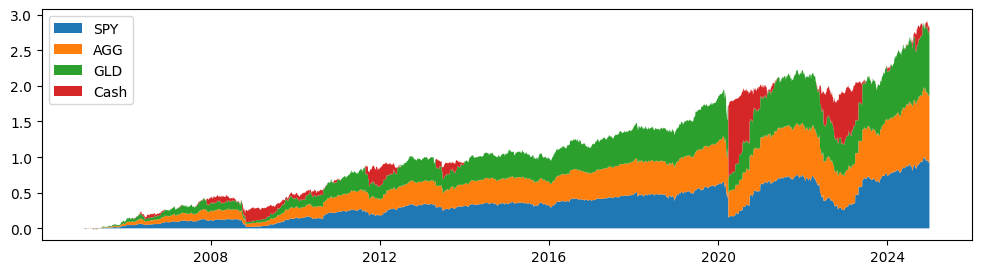

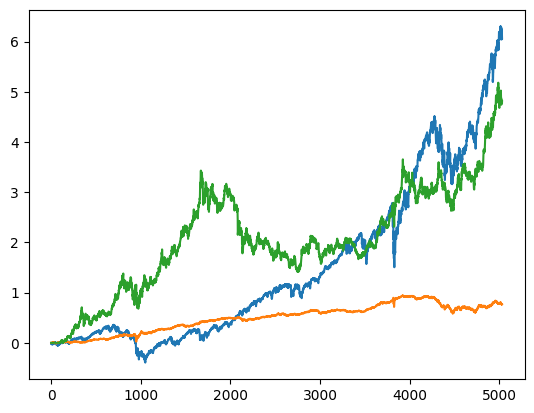

np.float64(0.08099082748315031)

In [5]:
dl._ret[~dl._asset_mask] = 1.0
plt.plot(dl._ret.cumprod(axis=0)-1.0)
plt.show()
sim.pw[:,-1].mean()

In [6]:
dl.universe

Index(['AGG', 'BTC-USD', 'CANE', 'CORN', 'CPER', 'DBA', 'DBB', 'DBC', 'EEM',
       'EWA', 'EWC', 'EWD', 'EWG', 'EWH', 'EWJ', 'EWL', 'EWP', 'EWS', 'EWT',
       'EWU', 'EWW', 'EWY', 'EWZ', 'GLD', 'IBB', 'IYR', 'LQD', 'PPLT', 'QQQ',
       'SLV', 'SOYB', 'SPY', 'TIP', 'TLT', 'UNG', 'USO', 'WEAT', 'WOOD', 'XLB',
       'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY'],
      dtype='str', name='Ticker')

In [7]:
# riskmodel/k10_lb6m_hc6m_hv2m.npz
# FIRST_DATE = "2005-01-03"
# FINAL_DATE = "2024-12-31"
# SPREAD = 5e-4
# LEVERAGE = 0.0
# VC_LIMIT = 0.08
# REBAL_FREQ = "M"
# m = Markowitz(
#     dl=dl,
#     lookahead=0,
#     gamma=SPREAD,
#     lev=LEVERAGE,
#     w_max=np.array([0.7, 0.2, 0.7, 0.7]),
#     vc_lim=VC_LIMIT,
# )
# Backtest Runtime: 1292 ms
# Ann Sharpe: 0.8134
# Ann Ret:    0.0873
# Ann Vol:    0.0855

In [8]:
# from time import time
# start = time()
# for i in range(100):
#     run_backtest(
#         strategy=fw,
#         spread=SPREAD
#     )
# print(time() - start)

In [9]:
# tickers = ["LQD", "SMH", "XLK", "AGG"] # , "QQQ", "GLD", "AGG", "XLK"
# # tickers = ["QQQ", "AGG", "XLK"]
# for t in tickers:
#     assert t in assets_remaining

# op = mod.OptimizerParams(
#     w_prev=np.zeros(len(tickers)),
#     w_max=0.7,
#     gamma=2e-4,
#     L=0.0,
#     vc_lim=((1.08)**(1/252))-1.0,
# )

# # data_bt["alpha"] = np.ones_like(data_bt["alpha"])

# lookahead = 0  # months
# holdings: pd.DataFrame = mod.run_backtest(
#     tickers=tickers,
#     universe=rd.columns,
#     data_bt=data_bt,
#     lookahead=lookahead,
#     op=op,
#     fixed_weights=False,
# )

# # r_tot = (performance+1).prod() - 1 
# # w_avg = weights.round(3).mean(axis=0).round(3)
# # vol_ann = performance.std() * 12**0.5 * 100 # realized

# # print(f"Sharpe ratio: {sharpe:8.3f}")
# # print(f"Period return: {r_tot:7.3f}")
# # print(f"Avg weights: {w_avg}")
# # print(f"Realized vol: {vol_ann:7.3}%")
# # print(f"Period: {START_DATE} : {END_DATE}")

# nav = holdings.sum(axis=1)
# w_port = holdings.div(nav, axis=0)

# rp = nav.pct_change().dropna()
# rf = ffr["DFF"].reindex(rp.index)
# mod.sharpe_ratio(rp, rf).round(3).item()

In [10]:
# |------------.------.---.--.-|-|
#                              t 
# The first 2 years (minus a day) are lost due to lookback (trailing returns)
# The last 1 month is lost due to trying to predict the future month - no lookahead!

# # plotting thetas over time
# features_all = ["Const"] + features_ret + features_mac
# pd.DataFrame(theta.mean(axis=1), columns=features_all, index=df_ref.index).plot()
# plt.show()

# # plotting pca graph
# Am = data[assets_remaining[0]]
# Um, d, VmT = np.linalg.svd(Am)
# Um.shape, d.shape, VmT.shape
# d /= d.sum()

# plt.figure(figsize=(7,2))
# plt.plot(d.cumsum())
# plt.axhline(y=0.90, c="r")
# plt.title(f"PCA - {assets_remaining[0]}")
# # plt.axvline(x=8, c="k", ls=":")
# plt.show()

In [11]:
# NOTE Simple way of getting an alpha

# rd = rd.loc[START_DATE:END_DATE]
# rd = rd.loc[:, ~rd.isna().any(axis=0)]

# corr = rd.rolling(252).corr().dropna()
# corr_avg = corr.groupby(level=0).apply(lambda x: (x - np.eye(rd.shape[1])).mean(axis=0).abs())
# corr_avg

# ffr = ffr.reindex(rd.index)
# excess = rd.sub(ffr.values, axis=0)
# mu = excess.rolling(252).mean().dropna()
# sd = rd.rolling(252).std().dropna()
# shrp_sld = mu / sd * np.sqrt(252)

# beta = 1.0
# gamma = 1.0
# alphas = beta * shrp_sld - gamma * corr_avg
# rd = rd.reindex(alphas.index)

In [12]:
# alphas = df_prd.rank(axis=1)
# rd = rd.loc[alphas.index, assets_remaining]

# assert rd.isna().any().any() == False

# ffr = (ffr + 1)**(1/252) - 1  # transform to daily
# ffr = ffr.reindex(rd.index)
# assert ffr.isna().any().any() == False

# lookback = 42 # days
# data_bt = backtest_data(
#     alphas=alphas,
#     rd=rd,
#     ffr=ffr,
#     lookback=lookback, 
#     rebal_freq="M"
#     )
# data_bt.keys()